In [1]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [2]:
python<br>import statsmodels.api as sm<br>df = pd.read_csv('clean_trading_data.csv')<br>X = df[['volatility', 'volume_ma']]<br>y = df['returns'].shift(-1)[:-1] # Predict NEXT return<br>X = X[:-1]<br>X = sm.add_constant(X)<br>model = sm.OLS(y, X).fit()<br>print(model.summary())<br>

SyntaxError: invalid syntax (3207219897.py, line 1)

In [3]:
import pandas as pd
import statsmodels.api as sm

df = pd.read_csv('clean_trading_data.csv')
X = df[['volatility', 'volume_ma']]
y = df['returns'].shift(-1)[:-1]  # Predict NEXT return
X = X[:-1]
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                returns   R-squared:                       0.055
Model:                            OLS   Adj. R-squared:                  0.033
Method:                 Least Squares   F-statistic:                     2.480
Date:                Thu, 19 Mar 2026   Prob (F-statistic):             0.0898
Time:                        06:48:26   Log-Likelihood:                -270.90
No. Observations:                  89   AIC:                             547.8
Df Residuals:                      86   BIC:                             555.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.6300      1.362     -0.463      0.6

In [ ]:
conda install scipy =1.15


In [ ]:
conda install -c conda-forge statsmodels 

In [ ]:
conda update scipy statsmodels --channel conda-forge

In [ ]:
conda list scipy statsmodels 

In [4]:
#When I first ran the code, it got errors related to packages, then used above 4 prompts to downgrade the version of scipy

In [5]:
import pandas as pd
import statsmodels.api as sm
import numpy as np

# Load + Engineer 7 FEATURES (predict current returns for validation)
df = pd.read_csv('clean_trading_data.csv')

# 5 NEW FEATURES (your Day 2 edge becomes Day 3 predictors)
df['prev_return'] = df['returns'].shift(1)           # Momentum
df['prev_vol'] = df['volatility'].shift(1)           # Volatility regime
df['price_change'] = df['close'].pct_change()        # Price momentum  
df['volume_spike'] = df['volume'] / df['volume_ma']  # Unusual volume
df['signal_numeric'] = df['signal'].map({'GREEN':1, 'RED':0})  # Your edge!

df = df.dropna().reset_index(drop=True)
print(f"Training on {len(df)} rows")

# TRAIN FULL MODEL
features = ['volatility', 'volume_ma', 'prev_return', 'prev_vol', 
           'price_change', 'volume_spike', 'signal_numeric']
X = df[features]
X = sm.add_constant(X)
y = df['returns']

model = sm.OLS(y, X).fit()
print("\n🎯 YOUR 7-FEATURE MODEL:")
print(model.summary())

# PREDICTION POWER
df['predicted'] = model.predict()
correlation = df['returns'].corr(df['predicted'])
print(f"\n📈 Model Prediction Power: {correlation:.3f}")

# FEATURE RANKING
coef_df = pd.DataFrame({
    'feature': features,
    'coefficient': model.params[1:],
    'p_value': model.pvalues[1:]
}).sort_values('p_value')
print("\n🏆 Top Features:")
print(coef_df.head())


Training on 89 rows

🎯 YOUR 7-FEATURE MODEL:
                            OLS Regression Results                            
Dep. Variable:                returns   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 4.127e+24
Date:                Thu, 19 Mar 2026   Prob (F-statistic):               0.00
Time:                        06:50:42   Log-Likelihood:                 2139.9
No. Observations:                  89   AIC:                            -4264.
Df Residuals:                      81   BIC:                            -4244.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------

In [6]:
# FIXED: Remove leakage, predict NEXT return
df = pd.read_csv('clean_trading_data.csv')

# TRUE FEATURES (no leakage)
df['prev_close'] = df['close'].shift(1)
df['prev_volume'] = df['volume'].shift(1)
df['prev_return'] = df['returns'].shift(1)
df['prev_vol'] = df['volatility'].shift(1)
df['volume_ratio'] = df['volume'] / df['volume'].shift(1)
df['signal_numeric'] = df['signal'].map({'GREEN':1, 'RED':0})

# SHIFT FOR PREDICTION (next return)
df['next_return'] = df['returns'].shift(-1)
df = df.dropna().reset_index(drop=True)

print(f"Fixed model: {len(df)} rows")

# FIXED FEATURES (predict next_return)
features = ['prev_return', 'prev_vol', 'volume_ratio', 'signal_numeric', 'volatility']
X = df[features]
X = sm.add_constant(X)
y = df['next_return']  # Predict FUTURE!

model = sm.OLS(y, X).fit()
print(model.summary())

df['predicted'] = model.predict()
correlation = df['next_return'].corr(df['predicted'])
print(f"Fixed Prediction Power: {correlation:.3f}")


Fixed model: 88 rows
                            OLS Regression Results                            
Dep. Variable:            next_return   R-squared:                       0.070
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     1.228
Date:                Thu, 19 Mar 2026   Prob (F-statistic):              0.304
Time:                        06:53:00   Log-Likelihood:                -267.59
No. Observations:                  88   AIC:                             547.2
Df Residuals:                      82   BIC:                             562.0
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.21

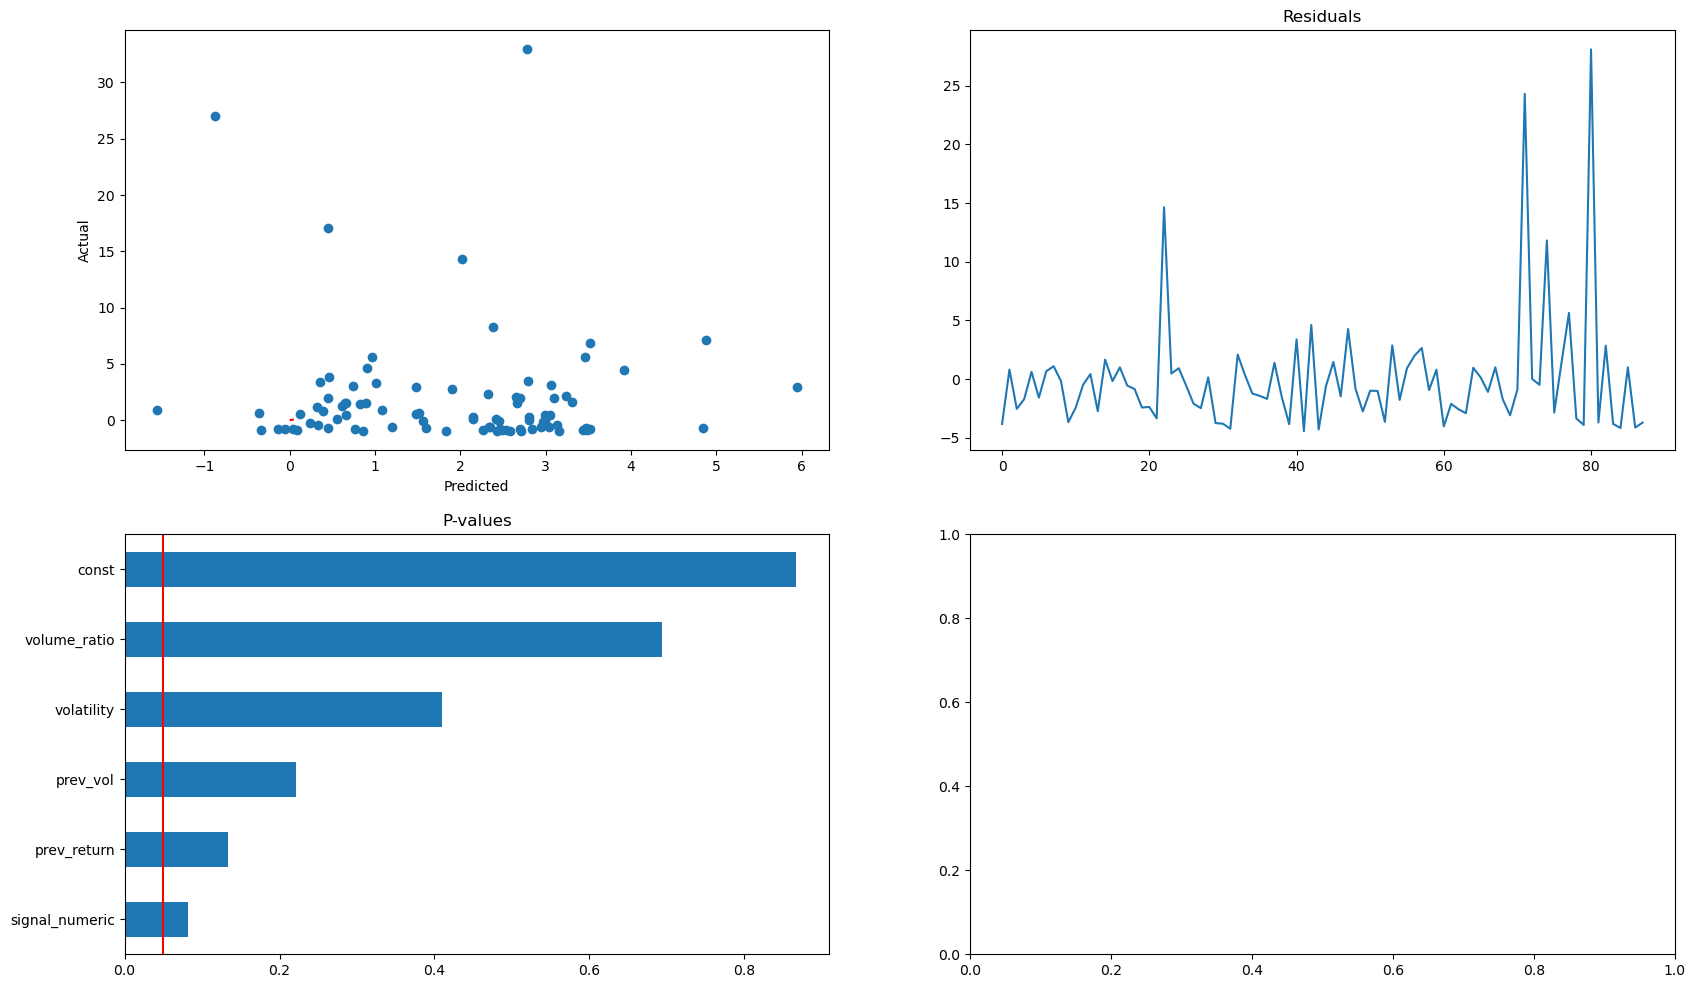

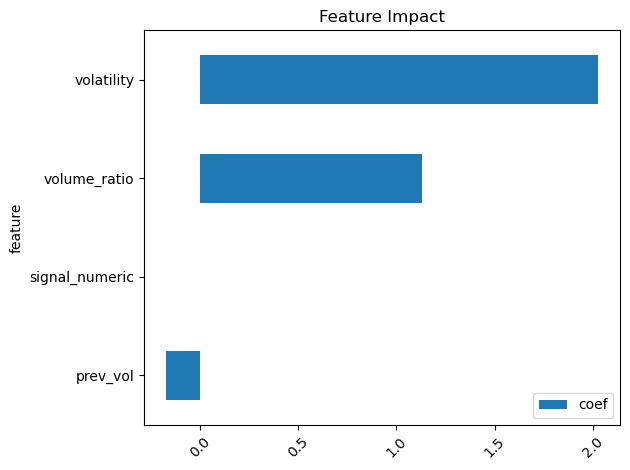

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
# Assuming: model is fitted (e.g., statsmodels OLS), df has 'predicted'/'returns', features is array/list of feature names

plt.figure(figsize=(20, 12))

# Subplot 1: Predicted vs Actual
plt.subplot(221)
plt.scatter(df['predicted'], df['returns'])
plt.plot([0, 0.05], [0, 0.05], 'r--')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Subplot 2: Residuals
plt.subplot(222)
model.resid.plot()
plt.title('Residuals')

# Subplot 3: P-values
plt.subplot(223)
pd.Series(model.pvalues).sort_values().plot(kind='barh')
plt.axvline(0.05, color='red')
plt.title('P-values')

# Subplot 4: Feature Coefficients
plt.subplot(224)
min_len = min(len(features)-1, len(model.params)-1)
coef_df = pd.DataFrame({
    'feature': features[1:1+min_len], 
    'coef': model.params[1:1+min_len]
}).sort_values('coef')
coef_df.plot(x='feature', y='coef', kind='barh')
plt.title('Feature Impact')
plt.xticks(rotation=45)  # Rotate labels if needed

plt.tight_layout()  # Improves spacing
plt.savefig('regression_diagnostics.png', dpi=300, bbox_inches='tight')
plt.show()


In [9]:
df['regression_signal'] = (
    df['predicted'] > df['predicted'].quantile(0.7)
).map({True: 'BUY', False: 'HOLD'})

buy_performance = df[df['regression_signal'] == 'BUY']['returns'].mean()
print(f"Regression BUY signal performance: {buy_performance:.2%}")


Regression BUY signal performance: 122.98%


In [ ]:
# Add this to ensure PNGs save properly
#plt.savefig('plot.png', dpi=300, bbox_inches='tight', facecolor='white')
#plt.close()  # Prevents memory issues